In [1]:
# %%
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

# For smooth "line not histogram" curves while keeping y-axis in COUNTS:
# We'll use scipy KDE and scale it by N * bin_width so area matches expected counts.
from scipy.stats import gaussian_kde

# %%
TEMPORAL_PATH = Path("/home/ahallur1/spear/Seamless_Experiments/Temporal/temporal_master.csv")
MASTER_PATH   = Path("/home/ahallur1/spear/Seamless_Experiments/Master/seamless_features.csv")

df_t = pd.read_csv(TEMPORAL_PATH)
df_m = pd.read_csv(MASTER_PATH)

print("Temporal:", df_t.shape, "Master:", df_m.shape)
df_t.head()

Temporal: (129215, 13) Master: (129215, 73)


,orig_id,wav_path,total_duration_s,speech_active_time_s,pause_count,pause_total_duration_s,pause_mean_duration_s,pause_ratio,speech_rate_wps,speech_rate_wpm,articulation_rate_wps,articulation_rate_wpm,status
0,V00_S0644_I00000129_P0799,V00_S0644_I00000129_P0799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_VALID_30S_STRETCH
1,V00_S0925_I00000135_P0383,V00_S0925_I00000135_P0383,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_VALID_30S_STRETCH
2,V00_S2050_I00001126_P1308A,V00_S2050_I00001126_P1308A,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_VALID_30S_STRETCH
3,V00_S0054_I00000785_P0084,V00_S0054_I00000785_P0084,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_VALID_30S_STRETCH
4,V00_S0086_I00000581_P0127,V00_S0086_I00000581_P0127,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NO_VALID_30S_STRETCH


In [2]:
# %%
# Keep only valid rows for temporal metrics
# temporal_master.csv has many rows with status like NO_VALID_30S_STRETCH and empty metrics.
df_t_valid = df_t[df_t["status"] == "OK"].copy()

# Ensure numeric columns are numeric
num_cols = [
    "speech_rate_wpm",
    "articulation_rate_wpm",
    "pause_ratio",
    "pause_mean_duration_s",
]
for c in num_cols:
    df_t_valid[c] = pd.to_numeric(df_t_valid[c], errors="coerce")

df_t_valid = df_t_valid.dropna(subset=num_cols)
print("Temporal valid:", df_t_valid.shape)
df_t_valid.describe()[num_cols]

Temporal valid: (45767, 13)


,speech_rate_wpm,articulation_rate_wpm,pause_ratio,pause_mean_duration_s
count,45767.000000,45767.000000,45767.000000,45767.000000
mean,178.367511,243.016165,0.267617,0.610596
std,31.298039,33.885204,0.064649,0.352868
min,2.341007,2.341007,0.000000,0.000000
25%,158.515331,222.125013,0.224156,0.523051
50%,178.162326,243.239283,0.264426,0.584245
75%,198.203663,264.591779,0.306537,0.654691
max,324.303701,390.823521,0.848077,34.084000


In [5]:
# %%
# Pull gender + relationship from seamless_features.csv and merge.
# We use wav_path as key.
# If temporal_master wav_path is orig_id-style (like V00_S...),
# it should match master 'orig_id' and often 'wav_path' too; but we'll merge on wav_path first.
meta_cols = ["orig_id", "gender", "relationship"]

df_meta = df_m[meta_cols].copy()

# Normalize text a bit
df_meta["gender"] = df_meta["gender"].astype(str).str.strip().str.lower()
df_meta["relationship"] = df_meta["relationship"].astype(str).str.strip().str.lower()

df_plot = df_t_valid.merge(df_meta, on="orig_id", how="left")


print("Merged plot df:", df_plot.shape)
print("gender NA:", df_plot["gender"].isna().mean(), "relationship NA:", df_plot["relationship"].isna().mean())
df_plot[["gender","relationship"]].value_counts(dropna=False).head(10)

Merged plot df: (45767, 15)
gender NA: 0.0 relationship NA: 0.0


gender  relationship
male    stranger        14651
female  stranger        13216
male    familiar         8503
female  familiar         8202
        unknown           461
male    unknown           426
nan     stranger          194
        familiar          107
        unknown             7
Name: count, dtype: int64

In [6]:
# %%
def _fd_bin_width(x: np.ndarray) -> float:
    """
    Freedman–Diaconis bin width.
    Returns a reasonable fallback if IQR=0 or n too small.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    n = x.size
    if n < 2:
        return 1.0
    q75, q25 = np.percentile(x, [75, 25])
    iqr = q75 - q25
    if iqr <= 0:
        # fallback: Scott's rule-ish using std
        s = np.std(x)
        if s <= 0:
            return 1.0
        return 3.5 * s / (n ** (1/3))
    return 2.0 * iqr / (n ** (1/3))


def kde_count_curve(
    x: np.ndarray,
    grid: np.ndarray,
    bin_width: float,
    bw_method: str | float = "scott",
) -> np.ndarray:
    """
    Returns KDE evaluated on grid, scaled to "counts" units:
        count_density(x) ~= kde(x) * N * bin_width
    so y-axis corresponds to expected counts per bin_width.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size < 5:
        return np.full_like(grid, np.nan, dtype=float)

    kde = gaussian_kde(x, bw_method=bw_method)
    y = kde(grid) * x.size * bin_width
    return y


def robust_xlim(x: np.ndarray, lo=0.5, hi=99.5) -> tuple[float, float]:
    """
    Plotting limits based on percentiles (NOT clipping data).
    This avoids insane axes while keeping all points in computation.
    """
    x = np.asarray(x)
    x = x[np.isfinite(x)]
    if x.size == 0:
        return (0.0, 1.0)
    return (float(np.percentile(x, lo)), float(np.percentile(x, hi)))


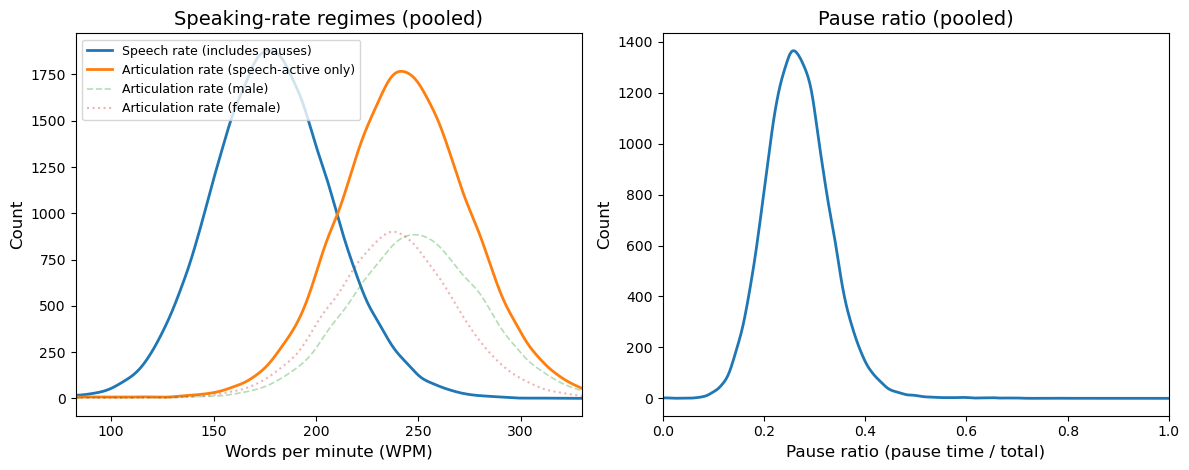

Saved: /home/ahallur1/spear/Seamless_Experiments/Temporal/paper_figures/Figure4_TemporalFlow.png


In [10]:
# %%
# ---- Figure 4 config ----
OUT_DIR = Path("/home/ahallur1/spear/Seamless_Experiments/Temporal/paper_figures")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Choose axis limits robustly (no clipping; just plot limits)
x_sr = df_plot["speech_rate_wpm"].to_numpy()
x_ar = df_plot["articulation_rate_wpm"].to_numpy()
x_pr = df_plot["pause_ratio"].to_numpy()

sr_lim = robust_xlim(x_sr, 0.5, 99.5)
ar_lim = robust_xlim(x_ar, 0.5, 99.5)
pr_lim = (0.0, 1.0)  # pause ratio is naturally bounded, so this is safe

# For panel A, set a shared x-range covering both metrics
xA_min = float(min(sr_lim[0], ar_lim[0]))
xA_max = float(max(sr_lim[1], ar_lim[1]))

# Bin width based on pooled distribution (for count scaling)
bw_A = _fd_bin_width(np.concatenate([x_sr[np.isfinite(x_sr)], x_ar[np.isfinite(x_ar)]]))
bw_B = _fd_bin_width(x_pr[np.isfinite(x_pr)])

# Grids for smooth curves
grid_A = np.linspace(xA_min, xA_max, 600)
grid_B = np.linspace(pr_lim[0], pr_lim[1], 600)

# Curves (pooled)
y_sr = kde_count_curve(x_sr, grid_A, bin_width=bw_A)
y_ar = kde_count_curve(x_ar, grid_A, bin_width=bw_A)
y_pr = kde_count_curve(x_pr, grid_B, bin_width=bw_B)

# Optional subtle gender overlay for articulation rate only
male_ar = df_plot.loc[df_plot["gender"] == "male", "articulation_rate_wpm"].to_numpy()
fem_ar  = df_plot.loc[df_plot["gender"] == "female", "articulation_rate_wpm"].to_numpy()
y_ar_m = kde_count_curve(male_ar, grid_A, bin_width=bw_A)
y_ar_f = kde_count_curve(fem_ar,  grid_A, bin_width=bw_A)

# ---- Plot ----
plt.figure(figsize=(12, 4.8))

# Panel A
ax1 = plt.subplot(1, 2, 1)
ax1.plot(grid_A, y_sr, label="Speech rate (includes pauses)", linewidth=2.0)
ax1.plot(grid_A, y_ar, label="Articulation rate (speech-active only)", linewidth=2.0)

# subtle gender overlays (thin, faint)
if np.isfinite(y_ar_m).any():
    ax1.plot(grid_A, y_ar_m, linestyle="--", linewidth=1.2, alpha=0.35, label="Articulation rate (male)")
if np.isfinite(y_ar_f).any():
    ax1.plot(grid_A, y_ar_f, linestyle=":", linewidth=1.5, alpha=0.35, label="Articulation rate (female)")

ax1.set_title("Speaking-rate regimes (pooled)", fontsize=14)
ax1.set_xlabel("Words per minute (WPM)", fontsize=12)
ax1.set_ylabel("Count", fontsize=12)
ax1.set_xlim(xA_min, xA_max)
ax1.legend(frameon=True, fontsize=9)

# Panel B
ax2 = plt.subplot(1, 2, 2)
ax2.plot(grid_B, y_pr, linewidth=2.0)
ax2.set_title("Pause ratio (pooled)", fontsize=14)
ax2.set_xlabel("Pause ratio (pause time / total)", fontsize=12)
ax2.set_ylabel("Count", fontsize=12)
ax2.set_xlim(pr_lim[0], pr_lim[1])

plt.tight_layout()
out_path = OUT_DIR / "Figure4_TemporalFlow.png"
plt.savefig(out_path, dpi=1200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)


In [11]:
from typing import Optional

def map_relationship(rel: str) -> Optional[str]:
    if not isinstance(rel, str):
        return None
    r = rel.strip().lower()
    if "familiar" in r:
        return "Familiar"
    if "stranger" in r:
        return "Stranger"
    return None

df_r = df_plot.copy()
df_r["rel2"] = df_r["relationship"].apply(map_relationship)
df_r = df_r[df_r["rel2"].isin(["Familiar", "Stranger"])].copy()

print(df_r["rel2"].value_counts(dropna=False))


rel2
Stranger    28061
Familiar    16812
Name: count, dtype: int64


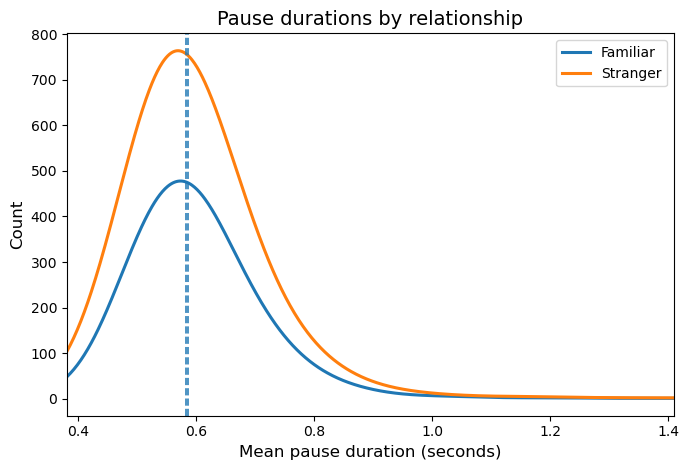

Saved: /home/ahallur1/spear/Seamless_Experiments/Temporal/paper_figures/Figure5_PauseMeanDuration_Relationship.png
Medians — Familiar: 0.5863265838011034 Stranger: 0.5828518518518591


In [12]:
# %%
x_pm_all = df_r["pause_mean_duration_s"].to_numpy()
pm_lim = robust_xlim(x_pm_all, 0.5, 99.5)
grid_pm = np.linspace(pm_lim[0], pm_lim[1], 700)
bw_pm = _fd_bin_width(x_pm_all[np.isfinite(x_pm_all)])

fam = df_r.loc[df_r["rel2"] == "Familiar", "pause_mean_duration_s"].to_numpy()
strg = df_r.loc[df_r["rel2"] == "Stranger",  "pause_mean_duration_s"].to_numpy()

y_fam  = kde_count_curve(fam,  grid_pm, bin_width=bw_pm)
y_strg = kde_count_curve(strg, grid_pm, bin_width=bw_pm)

med_fam  = float(np.nanmedian(fam))  if np.isfinite(fam).any()  else np.nan
med_strg = float(np.nanmedian(strg)) if np.isfinite(strg).any() else np.nan

plt.figure(figsize=(7.0, 4.8))
ax = plt.gca()

ax.plot(grid_pm, y_fam,  linewidth=2.2, label="Familiar")
ax.plot(grid_pm, y_strg, linewidth=2.2, label="Stranger")

# Median markers (vertical lines)
if np.isfinite(med_fam):
    ax.axvline(med_fam, linestyle="--", linewidth=1.4, alpha=0.8)
if np.isfinite(med_strg):
    ax.axvline(med_strg, linestyle="--", linewidth=1.4, alpha=0.8)

ax.set_title("Pause durations by relationship", fontsize=14)
ax.set_xlabel("Mean pause duration (seconds)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_xlim(pm_lim[0], pm_lim[1])
ax.legend(frameon=True, fontsize=10)

plt.tight_layout()
out_path = OUT_DIR / "Figure5_PauseMeanDuration_Relationship.png"
plt.savefig(out_path, dpi=1200, bbox_inches="tight")
plt.show()

print("Saved:", out_path)
print("Medians — Familiar:", med_fam, "Stranger:", med_strg)